# SRAM Data-Driven Analysis Pipeline

This notebook implements a modular post-processing pipeline for analyzing SRAM simulation outputs exported from Cadence.

The goal is to transform raw waveform data into structured performance metrics that can be used for architecture evaluation. Specifically, this pipeline focuses on:

- Extracting transient behavior from input/output signals
- Estimating switching delay based on threshold crossings
- Computing current, power, and energy consumption
- Analyzing SEU (Single Event Upset) response and recovery behavior
- Deriving stability-related indicators from SNM-related data

The overall workflow follows:

Cadence simulation → CSV export → Python processing → metrics extraction → visualization → design insights

This enables reproducible and scalable evaluation across different SRAM architectures.

## Environment Setup

In this section, we define project-level paths and ensure that all required directories exist.

The project is structured into:
- `data/`: raw CSV files exported from Cadence
- `src/`: modular Python code for data processing
- `results/`: generated figures and tables

We also append the `src/` directory to the Python path so that custom modules can be imported cleanly.

##

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "ESE5760_Final_Project" / "src"
DATA_DIR = PROJECT_ROOT / "ESE5760_Final_Project"/ "data"
RESULT_DIR = PROJECT_ROOT / "ESE5760_Final_Project" / "results"
FIG_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(SRC_DIR))

## Running the Analysis Pipeline

Here we execute the main analysis function, which loads all available CSV files and computes a set of standardized metrics.

The pipeline includes:
- Parsing waveform and multi-signal CSV formats
- Extracting signal-level features (e.g., transitions, extrema)
- Estimating delay between input and output nodes
- Computing power-related quantities from supply current
- Evaluating SEU behavior under different injection scenarios
- Generating a proxy metric for stability from SNM-related data

All outputs are stored in a structured dictionary for further inspection and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis import run_analysis
from src.plotting import plot_transient_signals, plot_seu_cases, plot_snm_curve

In [3]:
results = run_analysis(DATA_DIR)

## Transient Signal Characterization

This table summarizes the basic dynamic behavior of key signals.

For each signal, we extract:
- Initial and final values
- Minimum and maximum values
- Transition direction (rising or falling)
- Key crossing times (10%, 50%, 90%)
- Transition duration

These features provide insight into how quickly and reliably each node responds during operation.

In [4]:
results["transient_summary"]

,signal,initial_value,final_value,min_value,max_value,direction,t90,t50,t10,transition_time
0,D,1.100000,0.000002,-0.378516,1.100000,falling,1.006606e-09,1.013940e-09,1.022675e-09,1.606951e-11
1,D2,1.100000,1.100005,-0.378286,1.100008,rising,2.848461e-09,2.848461e-09,2.648461e-09,2.000000e-10
2,Q1B,0.545644,0.000003,-0.161040,0.845462,falling,7.542799e-12,1.000000e-11,1.347508e-11,5.932281e-12


## Delay Estimation

We estimate the propagation delay between input and output nodes using a 50% threshold crossing method.

Specifically:
- The input switching time is defined as the moment the signal crosses its midpoint
- The output response time is defined in the same way
- The delay is computed as the difference between these two timestamps

This provides a reasonable approximation of write or read latency in the bitcell.
The delay estimation is based on D-to-Q1B transitions as a proxy for write behavior, rather than a full wordline-controlled timing analysis.

In [5]:
# Delay is estimated using 50% crossing of input and output signals
results["delay_summary"]

,path,input_t50,output_t50,delay_s
0,D -> Q1B,1.013940e-09,1.000000e-11,-1.003940e-09


## Power and Energy Analysis

The supply current waveform is used to estimate power consumption.

We compute:
- Average current drawn from VDD
- Peak current during switching
- Instantaneous power using P = V × I
- Total energy per operation via time integration

These metrics allow us to evaluate both efficiency and dynamic behavior of the design.

In [6]:
# Convert supply current into power using P = VDD * I
results["power_summary"]

,signal,avg_current_A,peak_current_A,avg_power_W,peak_power_W,energy_J,charge_C
0,I(VDD),0.000024,0.000071,0.000026,0.000079,1.440819e-14,1.309836e-14


## SEU (Single Event Upset) Analysis

This section evaluates the robustness of the bitcell under transient disturbances.

For each injection scenario, we measure:
- Voltage drop magnitude (deviation from baseline)
- Time to reach minimum voltage
- Recovery time to 90%, 95%, and 99% of the original state
- Area below baseline (captures duration and severity of upset)

These metrics collectively describe how resilient the cell is to radiation-induced disturbances.

In [7]:
# Measure how much the node deviates from its baseline during SEU
results["seu_summary"]

,scenario,baseline_V,min_voltage_V,dip_V,min_time_s,recovery_90_s,recovery_95_s,recovery_99_s,area_below_baseline
0,/N0 (Qinj=1e-14),1.1,0.112222,0.987778,1.046281e-09,2.023626e-10,2.922706e-10,6.213829e-10,1.230339e-10
1,/N0 (Qinj=2.555556e-14),1.1,-0.533692,1.633692,1.019067e-09,3.792268e-10,4.744487e-10,7.179823e-10,3.481982e-10
2,/N0 (Qinj=1.033333e-13),1.1,-0.871664,1.971664,1.030092e-09,5.930244e-10,7.003512e-10,9.611666e-10,7.497096e-10


## Stability Indicator (SNM Proxy)

Due to the available data format, a direct butterfly curve-based SNM extraction is not performed.

Instead, we derive proxy metrics from the provided curve, including:
- Peak value of the curve
- Area under the curve

While not a strict SNM definition, these indicators still provide useful insight into relative stability trends.

In [8]:
results["snm_summary"]

,curve,peak_metric,peak_x,curve_area
0,Quatro_SNM_test,7.969166e-07,1.0881,5.004771e-09


## Visualization

The following plots illustrate the dynamic and robustness behavior of the design.

- Transient waveforms show how input signals propagate to internal nodes
- Current waveform highlights power consumption during switching
- SEU plots compare disturbance responses under different injection conditions
- SNM-related curve provides a qualitative view of stability

These visualizations support both quantitative analysis and intuitive understanding of circuit behavior.

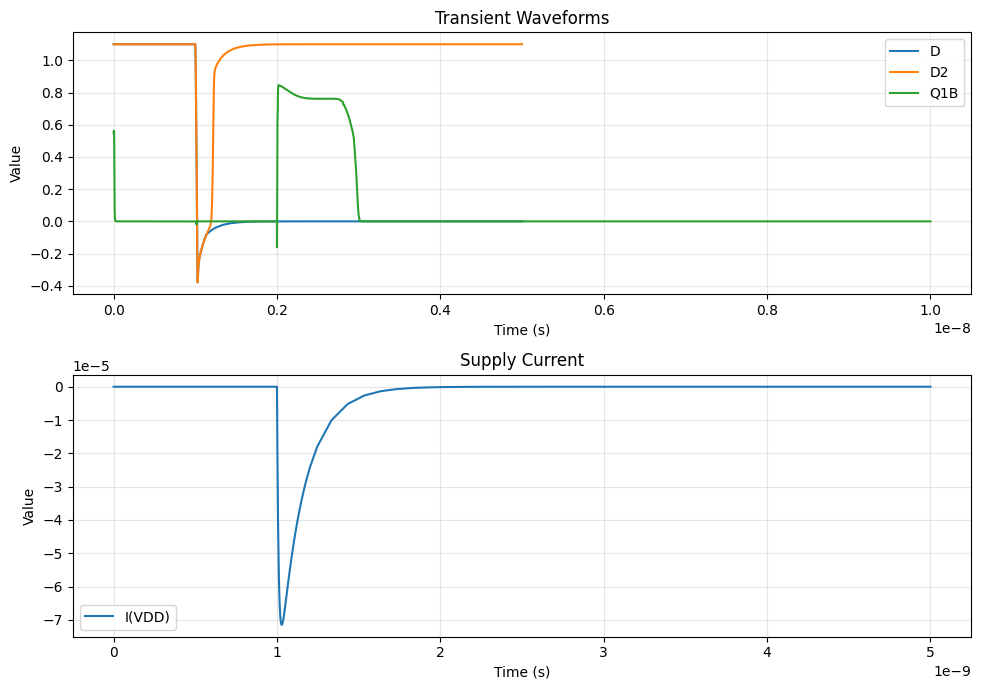

In [9]:
fig = plot_transient_signals(
    results["d"],
    results["d2"],
    results["q1b"],
    results["current"]
)
plt.show()

#if you want to save the figure, uncomment the line below
fig.savefig(FIG_DIR / "transient_signals.png", dpi=300)

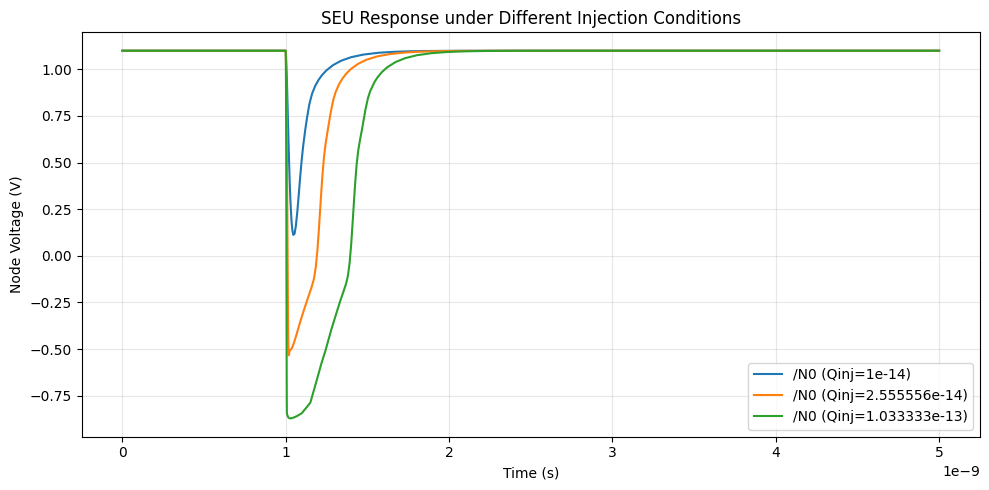

In [10]:
fig = plot_seu_cases(results["seu"])
plt.show()
#if you want to save the figure, uncomment the line below
fig.savefig(FIG_DIR / "seu_cases.png", dpi=300)

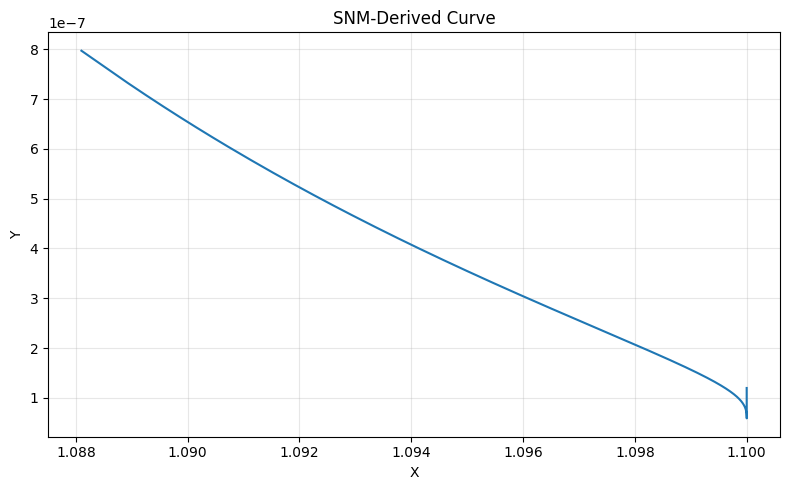

In [11]:
fig = plot_snm_curve(results["snm"])
plt.show()

#if you want to save the figure, uncomment the line below
fig.savefig(FIG_DIR / "snm_curve.png", dpi=300)

In [12]:
#if you want to save the tables, uncomment the lines below
results["transient_summary"].to_csv(TABLE_DIR / "transient_summary.csv", index=False)
results["delay_summary"].to_csv(TABLE_DIR / "delay_summary.csv", index=False)
results["power_summary"].to_csv(TABLE_DIR / "power_summary.csv", index=False)
results["seu_summary"].to_csv(TABLE_DIR / "seu_summary.csv", index=False)
results["snm_summary"].to_csv(TABLE_DIR / "snm_summary.csv", index=False)

## Key Observations

From the extracted metrics and visualizations, several observations can be made:

- The switching delay between input and output nodes is on the order of nanoseconds, indicating reasonable write performance
- The supply current shows clear peaks during transitions, with energy consumption concentrated around switching events
- Under SEU conditions, higher injection levels result in deeper voltage dips and longer recovery times, indicating increased vulnerability
- The stability-related curve suggests consistent behavior, with no obvious instability regions

Overall, the pipeline demonstrates that meaningful performance and robustness insights can be obtained directly from simulation data, enabling systematic comparison across designs.